In [1]:
from pathlib import Path

import cv2
import numpy as np

from tqdm import tqdm

import torch
import torch.nn as nn

from torchvision import models
from torchvision import transforms

from PIL import Image

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
PROJECT_PATH = Path("/content/drive/MyDrive/UAH_Project")

VIDEO_PATH = (
    PROJECT_PATH
    / "datasets"
    / "raw"
    / "UAH-DRIVESET-v1"
)

SENSOR_DATASET = (
    PROJECT_PATH
    / "datasets"
    / "processed"
    / "uah_dataset.npz"
)

In [16]:
video_paths = sorted(
    dataset_path.rglob("*.mp4")
)

print(len(video_paths))

for p in video_paths[:5]:
    print(p.name)

40
20151110175712-16km-D1-NORMAL1-SECONDARY.mp4
20151110180846-16km-D1-NORMAL2-SECONDARY.mp4
20151111123123-25km-D1-NORMAL-MOTORWAY.mp4
20151111125204-24km-D1-AGGRESSIVE-MOTORWAY.mp4
20151111132343-25km-D1-DROWSY-MOTORWAY.mp4


In [17]:
sensor = np.load(SENSOR_DATASET)

y = sensor["y"]
groups = sensor["groups"]

In [18]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

resnet = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

feature_extractor = nn.Sequential(
    *list(resnet.children())[:-1]
)

feature_extractor.to(device)

feature_extractor.eval()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 315MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225],
    )
])

In [19]:
def sample_representative_frames(
    video_path,
    num_frames=5,
):
    """
    Sample representative frames from a video.

    Returns
    -------
    frames : list[np.ndarray]
    """

    cap = cv2.VideoCapture(str(video_path))

    frame_count = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if frame_count == 0:
        cap.release()
        raise RuntimeError("Empty video")

    # %10 %30 %50 %70 %90
    positions = np.linspace(
        0.1,
        0.9,
        num_frames,
    )

    frame_indices = (
        positions * frame_count
    ).astype(int)

    frames = []

    for idx in frame_indices:

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            idx,
        )

        success, frame = cap.read()

        if not success:
            continue

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB,
        )

        frames.append(frame)

    cap.release()

    return frames

In [20]:
frames = sample_representative_frames(
    video_paths[0]
)

print(len(frames))

for frame in frames:
    print(frame.shape)

5
(540, 960, 3)
(540, 960, 3)
(540, 960, 3)
(540, 960, 3)
(540, 960, 3)


In [21]:
def extract_frame_feature(
    frame,
    feature_extractor,
    transform,
    device,
):
    image = Image.fromarray(frame)

    input_tensor = transform(image)
    input_tensor = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        feature = feature_extractor(input_tensor)

    feature = feature.squeeze().cpu().numpy()

    return feature

In [22]:
def extract_video_feature(
    frames,
    feature_extractor,
    transform,
    device,
):
    features = []

    for frame in frames:

        feature = extract_frame_feature(
            frame,
            feature_extractor,
            transform,
            device,
        )

        features.append(feature)

    features = np.stack(features)

    video_feature = features.mean(axis=0)

    return video_feature

In [23]:
feature = extract_video_feature(
    frames,
    feature_extractor,
    transform,
    device,
)

print(feature.shape)
print(feature.dtype)
print(feature[:20])

(2048,)
float32
[0.02891391 0.03190506 0.05083984 0.00332545 0.05175932 0.
 0.01347235 0.01214623 0.0089525  0.00679428 0.02265275 0.03815709
 0.06941464 0.0089737  0.01378045 0.11269833 0.00559323 0.07537226
 0.00411152 0.0286898 ]


In [24]:
video_embeddings = []

for video_path in tqdm(video_paths):

    frames = sample_representative_frames(
        video_path,
        num_frames=5,
    )

    feature = extract_video_feature(
        frames,
        feature_extractor,
        transform,
        device,
    )

    video_embeddings.append(feature)

video_embeddings = np.stack(video_embeddings)

print(video_embeddings.shape)

100%|██████████| 40/40 [02:46<00:00,  4.17s/it]

(40, 2048)


In [25]:
unique_groups = np.arange(40)

trip_labels = np.array([
    y[groups == trip][0]
    for trip in unique_groups
])

from sklearn.model_selection import train_test_split

train_groups, test_groups = train_test_split(
    unique_groups,
    test_size=0.20,
    random_state=42,
    stratify=trip_labels,
)

X_train = video_embeddings[train_groups]
X_test = video_embeddings[test_groups]

y_train = trip_labels[train_groups]
y_test = trip_labels[test_groups]

print(X_train.shape)
print(X_test.shape)

(32, 2048)
(8, 2048)


In [26]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42,
)

clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)

In [27]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print()

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "NORMAL",
            "DROWSY",
            "AGGRESSIVE",
        ],
    )
)

Accuracy: 0.625

              precision    recall  f1-score   support

      NORMAL       0.60      0.75      0.67         4
      DROWSY       0.50      0.50      0.50         2
  AGGRESSIVE       1.00      0.50      0.67         2

    accuracy                           0.62         8
   macro avg       0.70      0.58      0.61         8
weighted avg       0.68      0.62      0.62         8



In [28]:
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()

In [29]:
trip_ids = np.arange(len(video_embeddings))

preds = []
trues = []

In [30]:
for train_idx, test_idx in logo.split(
    video_embeddings,
    trip_labels,
    groups=trip_ids,
):

    clf = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42,
    )

    clf.fit(
        video_embeddings[train_idx],
        trip_labels[train_idx],
    )

    pred = clf.predict(
        video_embeddings[test_idx]
    )[0]

    preds.append(pred)

    trues.append(
        trip_labels[test_idx][0]
    )

In [31]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
)

print(
    "LOGO Accuracy:",
    accuracy_score(trues, preds)
)

print()

print(
    classification_report(
        trues,
        preds,
        target_names=[
            "NORMAL",
            "DROWSY",
            "AGGRESSIVE",
        ],
    )
)

LOGO Accuracy: 0.3

              precision    recall  f1-score   support

      NORMAL       0.27      0.35      0.31        17
      DROWSY       0.15      0.17      0.16        12
  AGGRESSIVE       0.80      0.36      0.50        11

    accuracy                           0.30        40
   macro avg       0.41      0.29      0.32        40
weighted avg       0.38      0.30      0.32        40



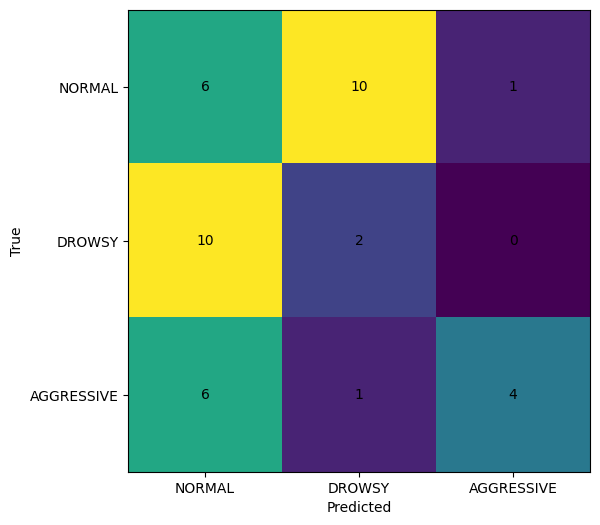

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(trues, preds)

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.xticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.yticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
        )

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [33]:
def sample_middle_frame(video_path):
    """
    Return the middle frame of a video.
    """

    cap = cv2.VideoCapture(str(video_path))

    frame_count = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    middle = frame_count // 2

    cap.set(
        cv2.CAP_PROP_POS_FRAMES,
        middle,
    )

    success, frame = cap.read()

    cap.release()

    if not success:
        raise RuntimeError(
            f"Cannot read {video_path.name}"
        )

    frame = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB,
    )

    return frame

In [34]:
frame = sample_middle_frame(video_paths[0])

print(frame.shape)

(540, 960, 3)


In [35]:
single_embeddings = []

for video_path in tqdm(video_paths):

    frame = sample_middle_frame(
        video_path
    )

    feature = extract_frame_feature(
        frame,
        feature_extractor,
        transform,
        device,
    )

    single_embeddings.append(feature)

single_embeddings = np.stack(single_embeddings)

print(single_embeddings.shape)

100%|██████████| 40/40 [00:15<00:00,  2.65it/s]

(40, 2048)


In [36]:
X_train = single_embeddings[train_groups]
X_test = single_embeddings[test_groups]

y_train = trip_labels[train_groups]
y_test = trip_labels[test_groups]

In [37]:
clf = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42,
)

clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)

In [38]:
y_pred = clf.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print()

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "NORMAL",
            "DROWSY",
            "AGGRESSIVE",
        ],
    )
)

Accuracy: 0.5

              precision    recall  f1-score   support

      NORMAL       0.50      0.25      0.33         4
      DROWSY       0.25      0.50      0.33         2
  AGGRESSIVE       1.00      1.00      1.00         2

    accuracy                           0.50         8
   macro avg       0.58      0.58      0.56         8
weighted avg       0.56      0.50      0.50         8



In [40]:
preds = []
trues = []

for train_idx, test_idx in logo.split(
    single_embeddings,
    trip_labels,
    groups=trip_ids,
):

    clf = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42,
    )

    clf.fit(
        single_embeddings[train_idx],
        trip_labels[train_idx],
    )

    pred = clf.predict(
        single_embeddings[test_idx]
    )[0]

    preds.append(pred)
    trues.append(trip_labels[test_idx][0])

print("LOGO Accuracy:", accuracy_score(trues, preds))

print(
    classification_report(
        trues,
        preds,
        target_names=[
            "NORMAL",
            "DROWSY",
            "AGGRESSIVE",
        ],
    )
)

LOGO Accuracy: 0.3
              precision    recall  f1-score   support

      NORMAL       0.31      0.29      0.30        17
      DROWSY       0.17      0.17      0.17        12
  AGGRESSIVE       0.42      0.45      0.43        11

    accuracy                           0.30        40
   macro avg       0.30      0.31      0.30        40
weighted avg       0.30      0.30      0.30        40



In [41]:
OUTPUT_PATH = (
    PROJECT_PATH
    / "datasets"
    / "processed"
)

np.save(
    OUTPUT_PATH / "video_embedding_5frames.npy",
    video_embeddings,
)

In [42]:
np.save(
    OUTPUT_PATH / "video_embedding_singleframe.npy",
    single_embeddings,
)